In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

pd.set_option('display.max_columns', None)

In [ ]:
import os

files = os.listdir('/content')
print("Files in /content:")
for f in files:
    print(f)

Files in /content:
.config
.ipynb_checkpoints
TMDB_all_movies.csv
sample_data


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/TMDB_all_movies.csv')

print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
df.head(3)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Shape: (1192309, 28)
Columns: ['id', 'title', 'vote_average', 'vote_count', 'status', 'release_date', 'revenue', 'runtime', 'budget', 'imdb_id', 'original_language', 'original_title', 'overview', 'popularity', 'tagline', 'genres', 'production_companies', 'production_countries', 'spoken_languages', 'cast', 'director', 'director_of_photography', 'writers', 'producers', 'music_composer', 'imdb_rating', 'imdb_votes', 'poster_path']


,id,title,vote_average,vote_count,status,release_date,revenue,runtime,budget,imdb_id,original_language,original_title,overview,popularity,tagline,genres,production_companies,production_countries,spoken_languages,cast,director,director_of_photography,writers,producers,music_composer,imdb_rating,imdb_votes,poster_path
0,2,Ariel,7.106,371.0,Released,1988-10-21,0.0,73.0,0.0,tt0094675,fi,Ariel,A Finnish man goes to the city to find a job a...,1.6384,NaN,"Comedy, Drama, Romance, Crime",Villealfa Filmproductions,Finland,suomi,"Kari Helaseppä, Jaakko Talaskivi, Mikko Remes,...",Aki Kaurismäki,Timo Salminen,Aki Kaurismäki,Aki Kaurismäki,NaN,7.4,9758.0,/ojDg0PGvs6R9xYFodRct2kdI6wC.jpg
1,3,Shadows in Paradise,7.300,435.0,Released,1986-10-17,0.0,74.0,0.0,tt0092149,fi,Varjoja paratiisissa,"Nikander, a rubbish collector and would-be ent...",2.7136,NaN,"Comedy, Drama, Romance",Villealfa Filmproductions,Finland,"svenska, suomi, English","Ari Korhonen, Mari Rantasila, Erkki Rissanen, ...",Aki Kaurismäki,Timo Salminen,Aki Kaurismäki,Mika Kaurismäki,NaN,7.4,8639.0,/nj01hspawPof0mJmlgfjuLyJuRN.jpg
2,5,Four Rooms,5.900,2821.0,Released,1995-12-09,4257354.0,98.0,4000000.0,tt0113101,en,Four Rooms,It's Ted the Bellhop's first night on the job....,4.0661,Twelve outrageous guests. Four scandalous requ...,Comedy,"Miramax, A Band Apart",United States of America,English,"David Proval, Tamlyn Tomita, Paul Skemp, Lana ...","Quentin Tarantino, Robert Rodriguez, Alexandre...","Andrzej Sekula, Rodrigo García, Phil Parmet, G...","Quentin Tarantino, Robert Rodriguez, Alexandre...","Quentin Tarantino, Alexandre Rockwell, Lawrenc...",Combustible Edison,6.7,116925.0,/75aHn1NOYXh4M7L5shoeQ6NGykP.jpg


In [ ]:
cols_to_drop = [
    'id',
    'original_title',
    'overview',
    'tagline',
    'imdb_id',
    'poster_path',
    'backdrop_path',
    'homepage',
]

cols_to_drop = [c for c in cols_to_drop if c in df.columns]
df = df.drop(columns=cols_to_drop)

print(f"Remaining columns ({len(df.columns)}): {df.columns.tolist()}")

Remaining columns (22): ['title', 'vote_average', 'vote_count', 'status', 'release_date', 'revenue', 'runtime', 'budget', 'original_language', 'popularity', 'genres', 'production_companies', 'production_countries', 'spoken_languages', 'cast', 'director', 'director_of_photography', 'writers', 'producers', 'music_composer', 'imdb_rating', 'imdb_votes']


In [ ]:
people_cols = ['director', 'cast', 'director_of_photography',
               'writers', 'producers', 'music_composer']

for col in people_cols:
    if col in df.columns:
        df[f'has_{col}'] = df[col].notna().astype(int)
        df = df.drop(columns=[col])

for col in ['production_companies', 'production_countries', 'spoken_languages']:
    if col in df.columns:
        df[f'has_{col}'] = df[col].notna().astype(int)
        df = df.drop(columns=[col])

print("People/production columns encoded as binary presence features ✓")
print(f"Columns now: {df.columns.tolist()}")

People/production columns encoded as binary presence features ✓
Columns now: ['title', 'vote_average', 'vote_count', 'status', 'release_date', 'revenue', 'runtime', 'budget', 'original_language', 'popularity', 'genres', 'imdb_rating', 'imdb_votes', 'has_director', 'has_cast', 'has_director_of_photography', 'has_writers', 'has_producers', 'has_music_composer', 'has_production_companies', 'has_production_countries', 'has_spoken_languages']


In [ ]:
df['is_english'] = (df['original_language'] == 'en').astype(int)
df = df.drop(columns=['original_language'])

print(f"English films: {df['is_english'].sum():,}")
print(f"Non-English films: {(df['is_english'] == 0).sum():,}")

Language encoded ✓
English films: 580,319
Non-English films: 611,990


In [ ]:
print(f"Starting rows: {len(df):,}")

df = df[df['budget'] > 0]
print(f"After budget filter: {len(df):,}")

df = df[df['revenue'] > 0]
print(f"After revenue filter: {len(df):,}")

df = df[df['vote_count'] >= 10]
print(f"After vote_count filter: {len(df):,}")

df = df[df['status'] == 'Released']
df = df.drop(columns=['status'])
print(f"After status filter (final): {len(df):,}")

Starting rows: 1,192,309
After budget filter: 78,737
After revenue filter: 17,755
After vote_count filter: 11,504
After status filter (final): 11,504


In [ ]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)

print(f"Total rows: {len(df):,}")
print("\nColumns with missing values:")
print(missing_df)

Total rows: 11,504

Columns with missing values:
              Missing Count  Missing %
genres                    5       0.04
imdb_rating               5       0.04
imdb_votes                5       0.04
release_date              3       0.03


In [ ]:
df = df.dropna(subset=['genres', 'imdb_rating', 'imdb_votes', 'release_date'])

print(f"Rows after dropping missing values: {len(df):,}")
print(df.isnull().sum().sum(), "total nulls left")

Rows after dropping missing values: 11,496
No missing values remain ✓
0 total nulls left


Success rate: 44.4%
success
0    6387
1    5109
Name: count, dtype: int64


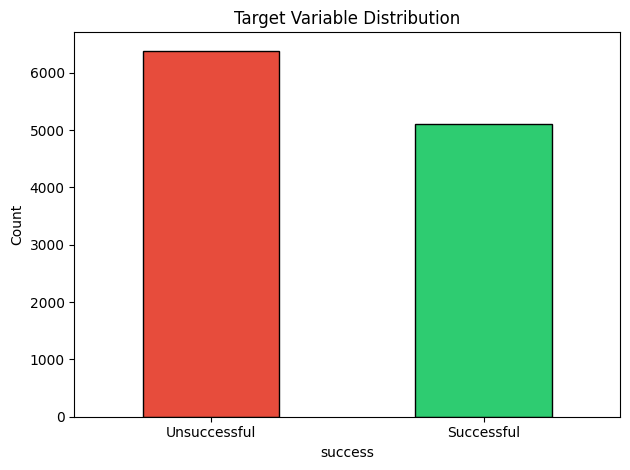

In [ ]:
df['success'] = (df['revenue'] > 2 * df['budget']).astype(int)

print(f"Success rate: {df['success'].mean():.1%}")
print(df['success'].value_counts())

df['success'].value_counts().plot(kind='bar', color=['#e74c3c', '#2ecc71'], edgecolor='black')
plt.title('Target Variable Distribution')
plt.xticks([0, 1], ['Unsuccessful', 'Successful'], rotation=0)
plt.ylabel('Count')
plt.tight_layout()
plt.savefig(DRIVE + 'class_distribution.png', dpi=150)
plt.show()

In [ ]:
for col in ['budget', 'revenue', 'popularity', 'imdb_votes']:
    df[f'log_{col}'] = np.log1p(df[col])

df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
df['release_month'] = df['release_date'].dt.month
df['release_year'] = df['release_date'].dt.year

df = df.drop(columns=['release_date', 'budget', 'revenue', 'popularity', 'imdb_votes'])


In [ ]:
genre_dummies = df['genres'].fillna('').str.get_dummies(sep=', ')
genre_dummies.columns = ['genre_' + c.strip() for c in genre_dummies.columns]
df = pd.concat([df, genre_dummies], axis=1)
df = df.drop(columns=['genres'])

print(f"Genre columns created: {[c for c in df.columns if c.startswith('genre_')]}")

Genre columns created: ['genre_Action', 'genre_Adventure', 'genre_Animation', 'genre_Comedy', 'genre_Crime', 'genre_Documentary', 'genre_Drama', 'genre_Family', 'genre_Fantasy', 'genre_History', 'genre_Horror', 'genre_Music', 'genre_Mystery', 'genre_Romance', 'genre_Science Fiction', 'genre_TV Movie', 'genre_Thriller', 'genre_War', 'genre_Western']


In [ ]:
df = df.drop(columns=['title'])

print(f"Final shape: {df.shape}")
print(f"Dtypes:\n{df.dtypes}")
print(f"\nAny remaining nulls: {df.isnull().sum().sum()}")

Final shape: (11496, 40)
Dtypes:
vote_average                   float64
vote_count                     float64
runtime                        float64
imdb_rating                    float64
has_director                     int64
has_cast                         int64
has_director_of_photography      int64
has_writers                      int64
has_producers                    int64
has_music_composer               int64
has_production_companies         int64
has_production_countries         int64
has_spoken_languages             int64
is_english                       int64
success                          int64
log_budget                     float64
log_revenue                    float64
log_popularity                 float64
log_imdb_votes                 float64
release_month                    int32
release_year                     int32
genre_Action                     int64
genre_Adventure                  int64
genre_Animation                  int64
genre_Comedy                   

In [ ]:
X = df.drop(columns=['success', 'log_revenue'])
y = df['success']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}")
print(f"Test:  {X_test.shape}")
print(f"Class balance in train:\n{y_train.value_counts()}")

Train: (9196, 38)
Test:  (2300, 38)
Class balance in train:
success
0    5109
1    4087
Name: count, dtype: int64


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
from sklearn.linear_model import LassoCV

lasso = LassoCV(cv=5, random_state=42, max_iter=5000)
lasso.fit(X_train_scaled, y_train)

selected_mask = lasso.coef_ != 0
selected_features = X_train.columns[selected_mask]

print(f"\nFeatures before Lasso: {X_train.shape[1]}")
print(f"Features after Lasso:  {len(selected_features)}")
print(f"\nRemoved: {X_train.columns[~selected_mask].tolist()}")
print(f"Kept:    {selected_features.tolist()}")

X_train_lasso = X_train_scaled[:, selected_mask]
X_test_lasso = X_test_scaled[:, selected_mask]

Running LassoCV — this may take 1-2 minutes...

Features before Lasso: 38
Features after Lasso:  35

Removed: ['has_producers', 'has_music_composer', 'has_production_countries']
Kept:    ['vote_average', 'vote_count', 'runtime', 'imdb_rating', 'has_director', 'has_cast', 'has_director_of_photography', 'has_writers', 'has_production_companies', 'has_spoken_languages', 'is_english', 'log_budget', 'log_popularity', 'log_imdb_votes', 'release_month', 'release_year', 'genre_Action', 'genre_Adventure', 'genre_Animation', 'genre_Comedy', 'genre_Crime', 'genre_Documentary', 'genre_Drama', 'genre_Family', 'genre_Fantasy', 'genre_History', 'genre_Horror', 'genre_Music', 'genre_Mystery', 'genre_Romance', 'genre_Science Fiction', 'genre_TV Movie', 'genre_Thriller', 'genre_War', 'genre_Western']


In [ ]:
selected_features_list = selected_features.tolist()

DRIVE_PATH = '/content/drive/MyDrive/'

np.save(DRIVE_PATH + 'X_train_lasso.npy', X_train_lasso)
np.save(DRIVE_PATH + 'X_test_lasso.npy', X_test_lasso)

X_train_df = pd.DataFrame(X_train_lasso, columns=selected_features_list)
X_test_df = pd.DataFrame(X_test_lasso, columns=selected_features_list)

X_train_df.to_csv(DRIVE_PATH + 'X_train.csv', index=False)
X_test_df.to_csv(DRIVE_PATH + 'X_test.csv', index=False)
y_train.to_csv(DRIVE_PATH + 'y_train.csv', index=False)
y_test.to_csv(DRIVE_PATH + 'y_test.csv', index=False)
df.to_csv(DRIVE_PATH + 'df_processed.csv', index=False)

pd.Series(selected_features_list).to_csv(DRIVE_PATH + 'selected_features.csv', index=False)

print(f"Final feature count: {len(selected_features_list)}")
print(f"Train size: {X_train_lasso.shape}")
print(f"Test size:  {X_test_lasso.shape}")

All files saved to Google Drive ✓
Final feature count: 35
Train size: (9196, 35)
Test size:  (2300, 35)
